# 04 — Classification: Prediksi Pelanggan High Value (Decision Tree)

Notebook ini melatih Decision Tree untuk memprediksi apakah seorang pelanggan termasuk kategori high value berdasarkan usia, kota, dan perilaku belanja.

## 1. Setup

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.insert(0, "/home/jovyan/work")

from analysis.spark_session import create_spark_session
spark = create_spark_session("04 - Classification")

## 2. Baca Data

In [2]:
BUCKET = "datalake"
df_features = spark.read.csv(f"s3a://{BUCKET}/processed/customer_features/", header=True, inferSchema=True)

print("Distribusi label is_high_value:")
df_features.groupBy("is_high_value").count().show()
df_features.show(5)

Distribusi label is_high_value:
+-------------+-----+
|is_high_value|count|
+-------------+-----+
|            1|   16|
|            0|   14|
+-------------+-----+

+-----------+-------------+--------+---+------------+-----------+-------------------+-------------+
|customer_id|customer_name|    city|age|total_orders|total_spend|avg_spend_per_order|is_high_value|
+-----------+-------------+--------+---+------------+-----------+-------------------+-------------+
|          1|         Andi|  Malang| 21|           4|    9545000|          2386250.0|            1|
|          2|         Budi|  Blitar| 22|           2|    8000000|          4000000.0|            1|
|          3|        Citra|Surabaya| 20|           2|    8880000|          4440000.0|            1|
|          4|         Dewi|  Kediri| 23|           2|    8000000|          4000000.0|            1|
|          5|          Eko| Jakarta| 25|           3|   12920000|         4306666.67|            1|
+-----------+-------------+--------

## 3. Latih Decision Tree

In [4]:
from analysis.mining.classification import run_decision_tree

df_predictions, auc = run_decision_tree(
    df_features,
    numeric_cols=["age", "total_orders", "total_spend", "avg_spend_per_order"],
    categorical_cols=["city"],
    label_col="is_high_value",
    test_ratio=0.2,
)

print(f"Area Under ROC (AUC): {auc:.3f}")
print("Hasil prediksi:")
df_predictions.select("customer_name", "city", "total_spend", "is_high_value", "prediction").show()

Area Under ROC (AUC): 1.000
Hasil prediksi:
+-------------+----------+-----------+-------------+----------+
|customer_name|      city|total_spend|is_high_value|prediction|
+-------------+----------+-----------+-------------+----------+
|        Citra|  Surabaya|    8880000|            1|       1.0|
|       Gilang|Yogyakarta|     320000|            0|       0.0|
|        Irfan|     Medan|     770000|            1|       1.0|
|         Nina|    Malang|      45500|            0|       0.0|
|         Tina|  Surabaya|      87500|            0|       0.0|
|         Xena|  Semarang|     400000|            0|       0.0|
|         Dian|    Malang|     365000|            0|       0.0|
+-------------+----------+-----------+-------------+----------+



## 4. Evaluasi Model

In [5]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="is_high_value", predictionCol="prediction")

accuracy  = evaluator.setMetricName("accuracy").evaluate(df_predictions)
f1        = evaluator.setMetricName("f1").evaluate(df_predictions)
precision = evaluator.setMetricName("weightedPrecision").evaluate(df_predictions)
recall    = evaluator.setMetricName("weightedRecall").evaluate(df_predictions)

print(f"Accuracy  : {accuracy:.3f}")
print(f"F1 Score  : {f1:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"AUC       : {auc:.3f}")

Accuracy  : 1.000
F1 Score  : 1.000
Precision : 1.000
Recall    : 1.000
AUC       : 1.000


## 5. Confusion Matrix

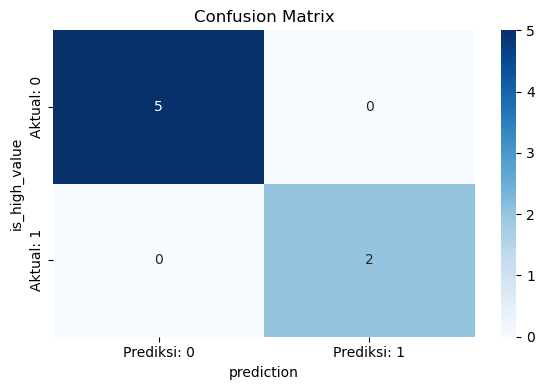

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Hitung confusion matrix
cm = df_predictions.groupBy("is_high_value", "prediction").count().toPandas()
matrix = cm.pivot(index="is_high_value", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Prediksi: 0","Prediksi: 1"],
            yticklabels=["Aktual: 0","Aktual: 1"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Simpan Hasil ke MinIO

In [7]:
# Drop kolom bertipe Vector — tidak kompatibel dengan format CSV
cols_to_drop = ["rawPrediction", "probability"]
df_to_save = df_predictions.drop(*[c for c in cols_to_drop if c in df_predictions.columns])

df_to_save.write.mode("overwrite").option("header", True) \
    .csv(f"s3a://{BUCKET}/processed/classification_results/")
print("Hasil klasifikasi disimpan ke processed zone.")

Hasil klasifikasi disimpan ke processed zone.
